In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
from jax.config import config as jax_config
jax_config.update("jax_enable_x64", True)
jax_config.update('jax_disable_jit', False)
import objax

import legogp as lego
from legogp import settings
from legogp.trainers import SimpleTrainer, ScipyTrainer, NatGradTrainer, GradDescentTrainer
from legogp.trainers.callbacks import progress_bar_callback
from legogp.kernels import Matern32, ScaleKernel
from legogp.likelihood import Gaussian, ReshapedGaussian
from legogp.data import TemporalData, Data, MultiOutputTemporalData
from legogp.models import GP
from legogp.sparsity import NoSparsity, StackedNoSparsity
from legogp.transforms import Independent, DataLatentPermutation
from legogp.transforms.multi_output import LMC
from legogp.approximate_posteriors import MeanFieldApproximatePosterior, MeanFieldConjugateGaussian, ConjugateGaussian, FullConjugateGaussian
from legogp.approximate_posteriors import FullGaussianApproximatePosterior, GaussianApproximatePosterior

import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np

from data_zoo import multi_output_timeseries

# Introduction


In the regression setting a variational GP can recover the standard GP in a single natural gradient step. The same is True for the linear model coregionalisation.

# Timeseries setting

In [3]:
# Fix randomness
np.random.seed(0)

P = 3
Q = 3

XS, X, Y = multi_output_timeseries(P, 100, 1000, seed=0)

Y_all = np.copy(Y)
#Y[10:30, 2] = np.NaN

config = {
    'ls': [0.1, 0.1, 0.1],
    'lik_var': [0.1, 0.1, 0.1],
    'epochs': 500,
    'lr': 0.01,
    'P': P,
    'Q': Q
}

res_time = {}

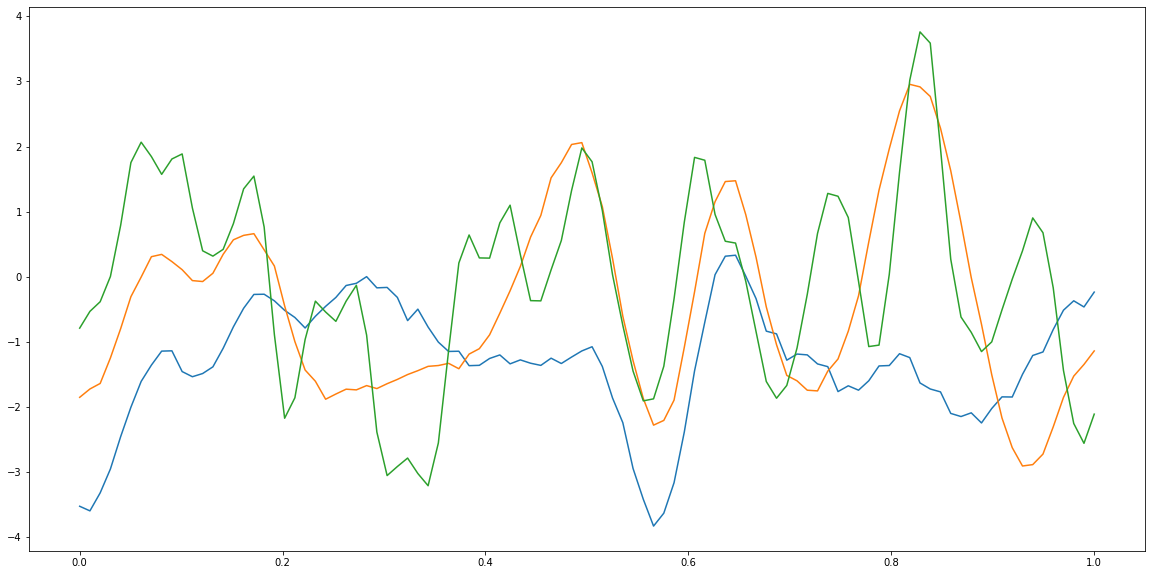

In [4]:
fig = plt.figure(figsize=(20, 10))
N = Y.shape[0]
for p in range(P):
    plt.plot(X, Y[:, p])

## Batch LMC

In [5]:
def batch_lmc(config, XS, X, Y):
    data = Data(X, Y)
    
    Z = NoSparsity(Z_ref=data._X)
    
    latents = [
        lego.models.GP(
            sparsity=Z, 
            kernel=Matern32(input_dim=1, lengthscales=[config['ls'][q]], active_dims=[0]),
            latent=True
        ) 
        for q in range(Q)
    ]
    
    prior = LMC(Independent(latents), output_dim = P)
    
    lik = [Gaussian(config['lik_var'][p]) for p in range(P)]
    
    m = GP(
        data = data,
        prior = prior,
        likelihood=lik,
        inference='Batch'
    )
    
    learning_curve, training_time = SimpleTrainer().train(
        m, 
        objax.optimizer.Adam,
        config['lr'],
        config['epochs'],
        callback = None
    )
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['batch'] = batch_lmc(config, XS, X, Y)

# Mean-Field Variational LMC

In [6]:
res_time = {}

def mf_vi_lmc(config, XS, X, Y):
    settings.ng_jitter = 1e-8
    data = Data(X, Y)
    
    Z = NoSparsity(Z_ref=data._X)
    
    latents = [
        lego.models.GP(
            sparsity=Z, 
            kernel=Matern32(input_dim=1, lengthscales=[config['ls'][q]], active_dims=[0]),
            latent=True
        ) 
        for q in range(Q)
    ]
    
    prior = LMC(Independent(latents), output_dim = P)
    
    lik = [Gaussian(config['lik_var'][p]) for p in range(P)]

    # get cvi params

    q_cvi = MeanFieldConjugateGaussian([
        ConjugateGaussian(
            X=Z,
            block_size=1,
            surrogate_model = lambda X, Y, likelihood:  lego.models.GP(
                data=Data(X=X.raw_Z, Y=Y[..., 0]), 
                prior=Independent([latents[q]]), 
                likelihood=likelihood[0],
                inference='Batch'
            ) # batch gp surrogate model 
        )
        for q in range(Q)
    ])

    cvi_posteriors = [q_cvi.approx_posteriors[q].surrogate.posterior(diagonal=False) for q in range(Q)]

    approx_posterior = MeanFieldApproximatePosterior(approximate_posteriors=[
        GaussianApproximatePosterior(m=cvi_posteriors[q][0][:, None], S=cvi_posteriors[q][1])
        for q in range(Q)
    ])
    
    m = GP(
        data = data,
        prior = prior,
        likelihood=lik,
        inference='Variational',
        approximate_posterior = approx_posterior
    )

    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')

    # Do not use adam for the approx posterios
    all_vars = list(m.vars().keys())
    m_name = [a for a in all_vars if a.endswith('._m(Parameter).raw_var')]
    s_chol_name = [a for a in all_vars if a.endswith('._S_chol(Parameter).raw_var')]
    approx_posterior_vars = m_name + s_chol_name

    grad_step = GradDescentTrainer(m, objax.optimizer.Adam, hold_vars = approx_posterior_vars)

    learning_curve = []
    for i in range(config['epochs']):
        try:
            obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
            grad_step.train(config['lr'], epochs=1)
            learning_curve.append(obj_val[0])
        except Exception as e:
            print(f'Exiting at {i}')
            break

    pred_mu, pred_var = m.predict_y(XS)

    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}

res_time['mf_vi'] = mf_vi_lmc(config, XS, X, Y)

## Mean-field CVI SDE LMC

In [7]:
def mf_cvi_sde_lmc(config, XS, X, Y):
    settings.ng_jitter = 1e-8
    settings.jitter=1e-8
    data = Data(X, Y)
    
    Z = [NoSparsity(Z_ref=data._X) for q in range(Q)]
    
    latents = [
        lego.models.GP(
            sparsity = Z[q], 
            kernel = Matern32(input_dim=1, lengthscales=[config['ls'][q]], active_dims=[0]),
            latent = True
        ) 
        for q in range(Q)
    ]
    
    prior = LMC(Independent(latents), output_dim = P)
    
    lik = [Gaussian(config['lik_var'][p]) for p in range(P)]
    
    q_cvi = MeanFieldConjugateGaussian([
        ConjugateGaussian(
            X=Z[q],
            block_size=1,
            surrogate_model = lambda X, Y, likelihood:  lego.models.GP(
                data=TemporalData(X=X.raw_Z, Y=Y, sort=False), # Data should already be in the correct format
                prior=Independent([latents[q]]), 
                likelihood=likelihood[0],
                inference='Sequential'
            ) # batch gp surrogate model 
        )
        for q in range(Q)
    ])

    m = GP(
        data = data,
        prior = prior,
        likelihood=lik,
        approximate_posterior=q_cvi,
        inference='Variational'
    )
    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam)
    
    learning_curve = []
    for i in range(config['epochs']):
        try:
            obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
            grad_step.train(config['lr'], epochs=1)
            learning_curve.append(obj_val[0])
        except Exception as e:
            print(e)
            print(f'Exiting at {i}')
            break
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['mf_sde_cvi'] = mf_cvi_sde_lmc(config, XS, X, Y)

## MF cvi batch lmc

In [8]:
def mf_cvi_batch_lmc(config, XS, X, Y):
    settings.ng_jitter = 1e-8
    data = Data(X, Y)
    
    Z = [NoSparsity(Z_ref=data._X) for q in range(Q)]
    
    latents = [
        lego.models.GP(
            sparsity = Z[q], 
            kernel = Matern32(input_dim=1, lengthscales=[config['ls'][q]], active_dims=[0]),
            latent = True
        ) 
        for q in range(Q)
    ]
    
    prior = LMC(Independent(latents), output_dim = P)
    
    lik = [Gaussian(config['lik_var'][p]) for p in range(P)]
    
    q_cvi = MeanFieldConjugateGaussian([
        ConjugateGaussian(
            X=Z[q],
            block_size=1,
            surrogate_model = lambda X, Y, likelihood:  lego.models.GP(
                data=Data(X=X.raw_Z, Y=Y[..., 0]), 
                prior=Independent([latents[q]]), 
                likelihood=likelihood[0],
                inference='Batch'
            ) # batch gp surrogate model 
        )
        for q in range(Q)
    ])

    m = GP(
        data = data,
        prior = prior,
        likelihood=lik,
        approximate_posterior=q_cvi,
        inference='Variational'
    )
    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam)
    
    learning_curve = []
    for i in range(config['epochs']):
        try:
            obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
            grad_step.train(config['lr'], epochs=1)
            learning_curve.append(obj_val[0])
        except Exception as e:
            print(e)
            print(f'Exiting at {i}')
            break
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['mf_batch_cvi'] = mf_cvi_batch_lmc(config, XS, X, Y)

# Dense Variational LMC

In [9]:
def dense_vi_lmc(config, XS, X, Y):
    settings.ng_jitter = 1e-8
    data = Data(X, Y)
    
    Z = NoSparsity(Z_ref=data._X)
    
    latents = [
        lego.models.GP(
            sparsity=Z, 
            kernel=Matern32(input_dim=1, lengthscales=[config['ls'][q]], active_dims=[0]),
            latent=True
        ) 
        for q in range(Q)
    ]
    
    prior = LMC(Independent(latents), output_dim = P)
    
    lik = [Gaussian(config['lik_var'][p]) for p in range(P)]
    
    m = GP(
        data = data,
        prior = DataLatentPermutation(prior),
        likelihood=lik,
        inference='Variational',
        approximate_posterior = FullGaussianApproximatePosterior(
            dim = Z.shape[0]*config['P']
        ),
        prediction_samples=1000
    )
    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    
    # Do not use adam for the approx posterios
    all_vars = list(m.vars().keys())
    m_name = [a for a in all_vars if a.endswith('._m(Parameter).raw_var')]
    s_chol_name = [a for a in all_vars if a.endswith('._S_chol(Parameter).raw_var')]
    approx_posterior_vars = m_name + s_chol_name
            
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam, hold_vars = approx_posterior_vars)
    
    learning_curve = []
    for i in range(config['epochs']):
        obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
        learning_curve.append(obj_val[0])
        grad_step.train(config['lr'], epochs=1)
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['dense_vi'] = dense_vi_lmc(config, XS, X, Y)

/Users/ohamelijnck/Documents/projects/legogp/legogp/approximate_posteriors/gaussian_approximate_posterior.py:21: UserWarning: Approximate posterior 
  warnings.warn('Approximate posterior ')


# Dense CVI SDE LMC

In [10]:
def dense_sde_cvi_lmc(config, XS, X, Y):
    settings.ng_jitter = 1e-8
    data = Data(X, Y)
    
    Z = [NoSparsity(Z_ref=data._X) for q in range(Q)]
    Z_all = StackedNoSparsity(Z)
    
    latents = [
        lego.models.GP(
            sparsity = Z[q], 
            kernel = Matern32(input_dim=1, lengthscales=[config['ls'][q]], active_dims=[0]),
            latent = True
        ) 
        for q in range(Q)
    ]
    
    prior = LMC(Independent(latents), output_dim = P)
    
    lik = [Gaussian(config['lik_var'][p]) for p in range(P)]
    
    q_cvi = FullConjugateGaussian(
        X=Z_all,
        num_latents=Q,
        block_size=Q,
        surrogate_model = lambda X, Y, likelihood:  lego.models.GP(
            data=MultiOutputTemporalData(X=X.sparsity_arr[0], Y=Y[:, None, :], sort=False), # Data should already be in the correct format
            prior=prior.latent_obj, 
            likelihood=likelihood,
            inference='Sequential'
        )  
    )

    m = GP(
        data = data,
        prior = prior,
        likelihood=lik,
        approximate_posterior=q_cvi,
        inference='Variational',
        prediction_samples=1000
    )
    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam)
    
    learning_curve = []
    for i in range(config['epochs']):
        obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
        learning_curve.append(obj_val[0])
        grad_step.train(config['lr'], epochs=1)
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['dense_sde_cvi'] = dense_sde_cvi_lmc(config, XS, X, Y)

## Plot Learning rates

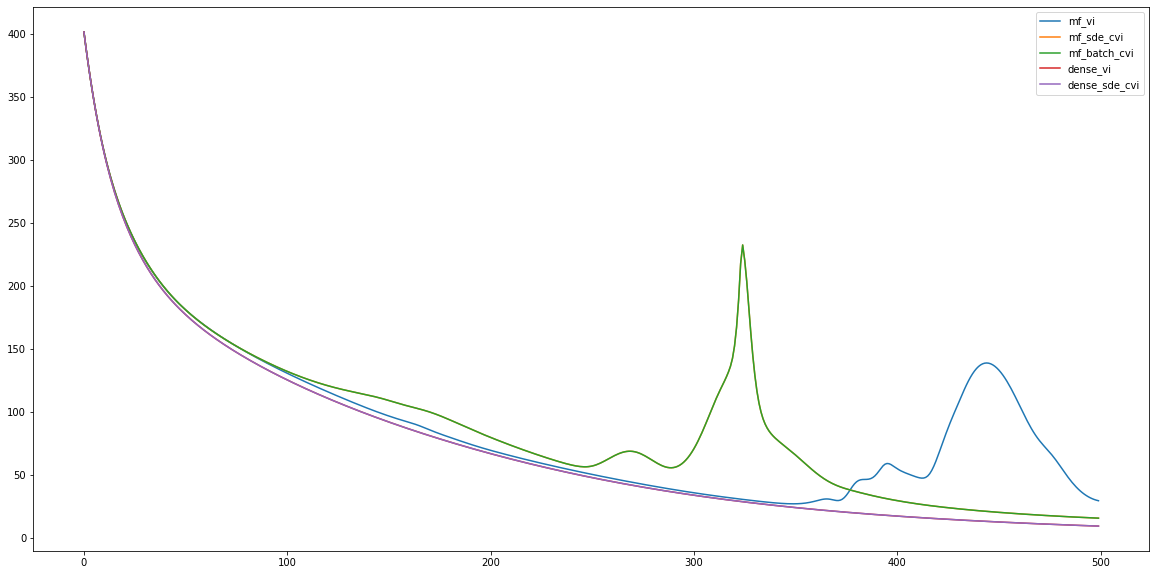

In [16]:
fig = plt.figure(figsize=(20, 10))
ax = plt.gca()
for m in res_time.keys():
    ax.plot(res_time[m]['lc'], label=m)
plt.legend()

# Predictions

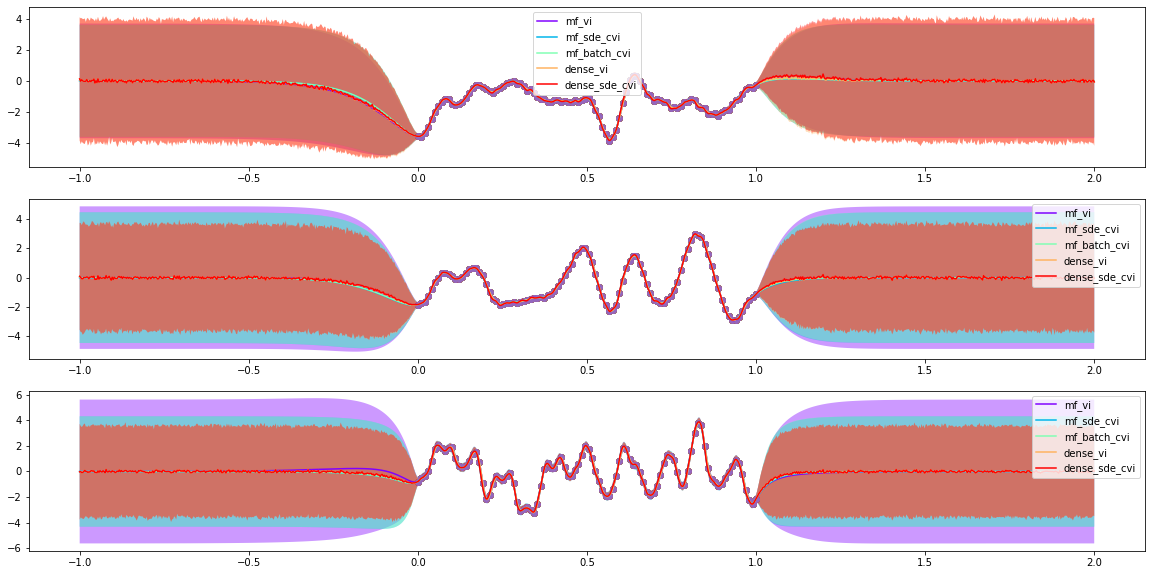

In [18]:
fig, axes = plt.subplots(P, 1, figsize=(20, 10))

color = cm.rainbow(np.linspace(0, 1, len(res_time.keys())))

#for m in ['batch', 'dense_sde_cvi']:
for i, m in enumerate(res_time.keys()):
    for p in range(P):
        axes[p].plot(XS, res_time[m]['pred_mu'][p], c=color[i], label=m)
        axes[p].fill_between(
            np.squeeze(XS), 
            np.squeeze(res_time[m]['pred_mu'][p]-1.96*np.sqrt(res_time[m]['pred_var'][p])), 
            np.squeeze(res_time[m]['pred_mu'][p]+1.96*np.sqrt(res_time[m]['pred_var'][p])),
            alpha=0.4,
            facecolor=color[i]
        )
            
        
        axes[p].scatter(X, Y_all[:, p])
    
for p in range(P):   
    axes[p].legend()

In [13]:
res_time.keys()

dict_keys(['mf_vi', 'mf_sde_cvi', 'mf_batch_cvi', 'dense_vi', 'dense_sde_cvi'])

In [14]:
res_time['mf_batch_cvi']['m'].print()

Y - 13: {'var': (100, 3)}
X - 7: {'var': (100, 1)}
Gaussian/variance - 10: {'var': array(0.00494402)}
Gaussian/variance - 11: {'var': array(0.00324072)}
Gaussian/variance - 12: {'var': array(0.01435473)}
(VGP)._prior(LMC)._latent_obj(Independent)._latents_arr(ModuleList)[0](GPPrior)._kernel(Matern32).lengthscale_param: {'var': array([0.12750887])}
(VGP)._prior(LMC)._latent_obj(Independent)._latents_arr(ModuleList)[1](GPPrior)._kernel(Matern32).lengthscale_param: {'var': array([0.12418712])}
(VGP)._prior(LMC)._latent_obj(Independent)._latents_arr(ModuleList)[2](GPPrior)._kernel(Matern32).lengthscale_param: {'var': array([0.05137138])}
W - 4: {'var': (3, 3)}
Y - 14: {'var': (100, 1)}
BlockGaussian/variance - 7: {'var': (100, 1, 1)}
(VGP).approximate_posterior(MeanFieldConjugateGaussian).approx_posteriors(ModuleList)[0](ConjugateGaussian).surrogate(BatchGP)._prior(Independent)._latents_arr(ModuleList)[0](GPPrior)._kernel(Matern32).lengthscale_param: {'var': array([0.12750887])}
Y - 15: {'

In [15]:
res_time['mf_vi']['m'].print()

Y - 2: {'var': (100, 3)}
X - 2: {'var': (100, 1)}
Gaussian/variance - 4: {'var': array(0.00578738)}
Gaussian/variance - 5: {'var': array(0.0038066)}
Gaussian/variance - 6: {'var': array(0.0138741)}
(VGP)._prior(LMC)._latent_obj(Independent)._latents_arr(ModuleList)[0](GPPrior)._kernel(Matern32).lengthscale_param: {'var': array([0.16203343])}
(VGP)._prior(LMC)._latent_obj(Independent)._latents_arr(ModuleList)[1](GPPrior)._kernel(Matern32).lengthscale_param: {'var': array([0.12806182])}
(VGP)._prior(LMC)._latent_obj(Independent)._latents_arr(ModuleList)[2](GPPrior)._kernel(Matern32).lengthscale_param: {'var': array([0.05101945])}
W - 2: {'var': (3, 3)}
GaussianApproxPosterior/m: {'var': (100, 1)}
GaussianApproxPosterior/S_chol: {'var': (5050,)}
GaussianApproxPosterior/m - 2: {'var': (100, 1)}
GaussianApproxPosterior/S_chol - 2: {'var': (5050,)}
GaussianApproxPosterior/m - 3: {'var': (100, 1)}
GaussianApproxPosterior/S_chol - 3: {'var': (5050,)}
